
Продолжаем четвертый модуль с основ RAG-систем — теперь уже семинар.

Collab семинара можно найти по [ссылке](https://colab.research.google.com/drive/1KwF06F2YJnYSZK3Bosl5RpETGg7SINP0?usp=sharing).

### Домашнее задание 11

1. **Выделить из собранного ранее датасета из ТГ-каналов/сайтов золотой набор** (либо руками, либо сгенерировать при помощи LLM)

   * оставить описание процесса сбора датасета;
     описать, какую часть вопросов из ретрива данный золотой набор покрывает и почему;
     объяснить выбор размера золотого набора — ***2 балла***
   * **бонусный балл** — за лексическое и лингвистическое разнообразие вопросов (ошибки, опечатки, различная длина и детализация вопросов) — ***1 балл***

2. **Протестировать ретриверы на золотом наборе:**

   * объяснить, по какому принципу считали "попадание" в контекст, какие метрики выбрали для оценки качества ретрива — ***1 балл***
   * протестировать различные ретриверы на данных, обосновать выбор — ***1 балл***
   * бонусный балл — протестировать методы query expansion и другие методы из langchain — ***1 балл***

3. **Добавить к системе реранкер, замерить улучшение/ухудшение качества ретрива**, замерить время, требуемое на запрос, и его изменение — ***1 балл***

4. **Протестировать оценку LLM-кой релевантности и выбора контекстов**, замерить улучшение/ухудшение качества ретрива, замерить время, требуемое на запрос, и его изменение — ***1 балл***

5. **Сгенерировать ответы модели на вопросы из золотого набора, разметить сгенерированные данные** — аргументировать метод разметки; если это LLM-as-a-judge, обосновать надёжность промпта и выбранного подхода — ***2 балла***

---

**Домашнее задание необходимо предоставить в формате ссылки на Google Colab/Jupyter Notebook с вашими действиями и ключевыми выводами.**

* 13 ноября 23:59 — мягкий дедлайн
* 20 ноября 23:59 — жесткий дедлайн

До мягкого дедлайна можно получить **10 баллов**, после — **5 баллов**.
Работы, отправленные после 20 ноября, могут быть проверены до конца курса в формате *зачет/незачет*.


In [1]:
!pip install -U datasets==3.6.0 huggingface_hub fsspec

  Using cached fsspec-2025.10.0-py3-none-any.whl.metadata (10 kB)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd

## Загрузка и подготовка данных

In [3]:
df = pd.read_csv('./data/channel_name.csv')
df.head()

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


In [ ]:
import matplotlib.pyplot as plt

df['word_count'] = df['text'].fillna('').str.split().str.len()

plt.hist(df['word_count'].values)
plt.title("Распределение количества слов в каждом посте");

### Метод выбора постов

In [ ]:
import pandas as pd

TARGET_POSTS = 80  

def categorize_post(text):
    text = text.lower()
    if "#event" in text: return "event"
    if "#video" in text: return "video"
    if "#article" in text: return "article"
    if "#packageoftheweek" in text: return "package"
    return "other"

df['category'] = df['text'].apply(categorize_post)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

selected_posts = set()

# --- 1) равномерный по времени срез (60% выборки) ---
time_target = int(TARGET_POSTS * 0.6)  # 48 постов
time_stride = max(1, len(df) // time_target)
time_ids = df.iloc[::time_stride]['id'].tolist()[:time_target]
selected_posts.update(time_ids)

# --- 2) равномерный по категориям срез (40% выборки) ---
cat_target = TARGET_POSTS - len(selected_posts)
cat_distribution = (df['category'].value_counts(normalize=True) * cat_target).round().astype(int)

for cat, cnt in cat_distribution.items():
    if cnt <= 0: continue
    cat_posts = df[(df['category']==cat) & (~df['id'].isin(selected_posts))]
    if len(cat_posts) == 0: continue
    
    stride = max(1, len(cat_posts) // cnt)
    selected_posts.update(cat_posts.iloc[::stride]['id'].tolist()[:cnt])

# --- 3) добить недостающее по дате ---
if len(selected_posts) < TARGET_POSTS:
    remaining = df[~df['id'].isin(selected_posts)]
    need = TARGET_POSTS - len(selected_posts)
    selected_posts.update(remaining.iloc[:need]['id'].tolist())

selected_posts = list(selected_posts)[:TARGET_POSTS]

print(f"✅ Выбрано постов: {len(selected_posts)}")
print(selected_posts)


In [ ]:
# selected_posts — список ID постов, которые мы выбрали
# Например: selected_posts = [1201, 1196, 1195, 1193]

# Получаем срез df только с выбранными постами
golden_df = df[df['id'].isin(selected_posts)].copy()

# Просмотр первых строк
golden_df.head()


In [ ]:
golden_df.shape

In [ ]:
golden_df.to_csv('./data/golden_df.csv')

## Задача 1

1. **Выделить из собранного ранее датасета из ТГ-каналов/сайтов золотой набор** (либо руками, либо сгенерировать при помощи LLM)

   * оставить описание процесса сбора датасета;
     описать, какую часть вопросов из ретрива данный золотой набор покрывает и почему;
     объяснить выбор размера золотого набора — ***2 балла***
   * **бонусный балл** — за лексическое и лингвистическое разнообразие вопросов (ошибки, опечатки, различная длина и детализация вопросов) — ***1 балл***

#### 1 Установка зависимостей

In [ ]:
!pip install openai pandas tqdm sentence-transformers editdistance python-dotenv


#### Импорт и настройка

In [65]:
import requests
import time

def chat_completion(messages, model="gpt-3.5-turbo", max_tokens=100, temperature=0.7,
                    url="http://localhost:8000/v1/chat/completions", delay=1.0, timeout=30):
    """
    Универсальный метод для отправки запросов к chat completion API с задержкой
    
    Args:
        messages (list): Список сообщений в формате [{"role": "...", "content": "..."}]
        model (str): Название модели
        max_tokens (int): Максимальное количество токенов в ответе
        temperature (float): Температура для генерации
        url (str): URL эндпоинта
        delay (float): Задержка в секундах перед запросом
    
    Returns:
        dict: Ответ от сервера или None в случае ошибки
    """
    
    time.sleep(delay)  # <-- добавляем задержку перед отправкой запроса
    
    headers = {"Content-Type": "application/json"}
    
    data = {
        "model": model,
        "max_tokens": max_tokens,
        "temperature": temperature,
        "messages": messages
    }
    
    try:
        response = requests.post(url, headers=headers, json=data, timeout=timeout)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при отправке запроса: {e}")
        return None


#### Генерация кандидатов через локальный LLM

In [ ]:
PROMPTS = {
    "fact_extraction": "Дай 5 вопросов, чтобы извлечь фактическую информацию из текста: '''{text}'''",
    "opinion_followup": "Сгенерируй 5 вопросов для обсуждения или мнений по тексту: '''{text}'''",
    "link_request": "Сгенерируй 4 вопроса, просящие ссылки/ресурсы/даты событий: '''{text}'''",
    "clarification": "Сгенерируй 4 уточняющих/неоднозначных вопроса по тексту: '''{text}'''"
}

def generate_questions_local(text, prompts=PROMPTS, model="gpt-3.5-turbo"):
    candidates = []
    for key, template in prompts.items():
        prompt = template.format(text=text)
        resp = chat_completion([{"role":"system","content":"Ты ассистент для генерации вопросов."},
                                {"role":"user","content":prompt}], model=model, max_tokens=300, temperature=0.9)
        if not resp: 
            continue
        out_text = resp['choices'][0]['message']['content']
        lines = re.split(r'[\n\r]+', out_text)
        for line in lines:
            line = line.strip()
            if line.endswith('?') or len(line.split()) <= 6:
                line = re.sub(r'^\d+\.\s*', '', line)
                candidates.append({"question": line, "prompt_type": key})
    return candidates


#### Генерация для всего датасета

In [ ]:
df = pd.read_csv('./data/golden_df.csv')
df.shape

In [ ]:
df.head()

In [ ]:
import os
import re
import json
import random
from typing import List, Dict, Any
import pandas as pd
from tqdm.auto import tqdm

df = pd.read_csv('./data/golden_df.csv')
df['date'] = pd.to_datetime(df['date'])

all_candidates = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    cands = generate_questions_local(row['text'])
    for c in cands:
        c['post_id'] = row['id']
    all_candidates.extend(cands)

candidates_df = pd.DataFrame(all_candidates).drop_duplicates(subset=['post_id','question'])


In [ ]:
candidates_df

In [ ]:
candidates_df.to_csv('./data/candidates_raw_df.csv')

#### Добавление опечаток

In [ ]:
def make_typos(q, n=2):
    letters = list(q)
    res = set()
    for _ in range(n*3):
        s = letters.copy()
        typ = random.choice(['swap','del','replace'])
        if typ == 'swap' and len(s) >= 2:
            i = random.randrange(len(s)-1)
            s[i], s[i+1] = s[i+1], s[i]
        elif typ == 'del' and len(s) >= 1:
            i = random.randrange(len(s))
            del s[i]
        elif typ == 'replace' and len(s) >= 1:
            i = random.randrange(len(s))
            s[i] = random.choice('абвгдеёжзийклмнопрстуфхцчшщьыъэюяaeiou')
        cand = ''.join(s)
        if cand != q: res.add(cand)
        if len(res) >= n: break
    return list(res)

augmented = []
for _, r in candidates_df.iterrows():
    augmented.append({**r, "variation_type": "original"})
    for t in make_typos(r['question']):
        augmented.append({**r, "question": t, "variation_type": "typo"})

candidates_df = pd.DataFrame(augmented).drop_duplicates(subset=['post_id','question'])


In [ ]:
candidates_df.to_csv('./data/candidates_df.csv')

In [ ]:
candidates_df

#### Семантическая диверсификация

In [ ]:
from sentence_transformers import SentenceTransformer, util

embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
questions = candidates_df['question'].tolist()
embs = embed_model.encode(questions, convert_to_tensor=True)

selected_indices = []
remaining = set(range(len(questions)))
start_idx = max(range(len(questions)), key=lambda i: len(questions[i]))
selected_indices.append(start_idx)
remaining.remove(start_idx)

while len(remaining) > 0 and len(selected_indices) < 200:
    best_idx, best_dist = None, -1
    for i in list(remaining):
        d = util.cos_sim(embs[i], embs[selected_indices]).min().item()
        if best_idx is None or d < best_dist:
            best_idx, best_dist = i, d
    if best_idx is None: break
    selected_indices.append(best_idx)
    remaining.remove(best_idx)

selected_candidates = candidates_df.iloc[selected_indices]


In [ ]:
selected_candidates.to_csv('./data/selected_candidates.csv')


## Скоринг через LLM

In [ ]:
SCORING_PROMPT = """
Оцени вопрос по тексту поста по шкале 1-5 (1 — плохо, 5 — отлично):
- relevance: насколько вопрос извлекает факты из поста
- clarity: насколько вопрос ясен
- retrievability: насколько вопрос полезен для поиска

Верни JSON: {{"relevance":int,"clarity":int,"retrievability":int,"avg":float,"note":"..."}} 

Пост:
'''{post}'''

Вопрос:
'''{question}'''
"""

def score_question_local(post_text, question, model="gpt-3.5-turbo"):
    prompt = SCORING_PROMPT.format(post=post_text, question=question)
    resp = chat_completion([{"role":"system","content":"Ты эксперт по оценке вопросов."},
                            {"role":"user","content":prompt}], model=model, max_tokens=150, temperature=0)
    if not resp:
        return {"relevance":3,"clarity":3,"retrievability":3,"avg":3.0,"note":"fallback"}
    out_text = resp['choices'][0]['message']['content']
    jtext = out_text[out_text.find('{'):out_text.rfind('}')+1] if '{' in out_text else None
    try:
        score = eval(jtext)
    except:
        score = {"relevance":3,"clarity":3,"retrievability":3,"avg":3.0,"note":"fallback"}
    return score


#### Финальный gold set

Рассчитываем максимально возможное количество вопросов

In [ ]:
MAX_PER_POST = 3  # максимум вопросов с одного поста

# Считаем, сколько кандидатов доступно по каждому посту
post_counts = selected_candidates.groupby('post_id')['question'].count()

# Максимальное количество вопросов, которое можно взять с каждого поста
post_max = post_counts.apply(lambda x: min(x, MAX_PER_POST))

# Общая сумма — максимально возможное TARGET_SIZE
max_target_size = post_max.sum()
print("Максимально возможное TARGET_SIZE:", max_target_size)

Устанавливаем динамический TARGET_SIZE

In [ ]:
# Желаемое количество вопросов, если достаточно кандидатов
desired_size = 24

# Фактическое TARGET_SIZE — минимум между желаемым и максимально возможным
TARGET_SIZE = min(desired_size, max_target_size)
print("Используемое TARGET_SIZE:", TARGET_SIZE)


Определяем желаемое распределение

In [ ]:
# Типы prompt
prompt_types = ["fact_extraction", "opinion_followup", "link_request", "clarification"]

# Желаемое количество вопросов на тип
# Например, равномерное распределение для TARGET_SIZE
per_type_count = TARGET_SIZE // len(prompt_types)
extra = TARGET_SIZE % len(prompt_types)  # остаток

type_quota = {t: per_type_count for t in prompt_types}
# Добавляем по одному из остатка к первым типам
for t in prompt_types[:extra]:
    type_quota[t] += 1

print("Квота по типам:", type_quota)


Динамический цикл набора golden set
Набор golden set с учётом типа prompt

In [ ]:
scores_list = []
per_post_count = {}
type_count = {t: 0 for t in prompt_types}

pbar = tqdm(total=TARGET_SIZE)

for _, r in selected_candidates.iterrows():
    if len(scores_list) >= TARGET_SIZE:
        break

    pid = r['post_id']
    ptype = r['prompt_type']

    # Проверяем лимит по посту и лимит по типу
    if per_post_count.get(pid, 0) >= MAX_PER_POST:
        continue
    if type_count.get(ptype, 0) >= type_quota.get(ptype, 0):
        continue

    post_text = df.loc[df['id'] == pid, 'text'].values[0]
    question = r['question']

    # Скоринг
    score = score_question_local(post_text, question)

    row = r.to_dict()
    row.update({
        "score_relevance": score["relevance"],
        "score_clarity": score["clarity"],
        "score_retrievability": score["retrievability"],
        "score_avg": score["avg"],
        "note": score["note"]
    })

    scores_list.append(row)
    per_post_count[pid] = per_post_count.get(pid, 0) + 1
    type_count[ptype] = type_count.get(ptype, 0) + 1
    pbar.update(1)

pbar.close()

gold_scored_df = pd.DataFrame(scores_list)
gold_scored_df.to_csv("gold_questions_local_scored.csv", index=False)
gold_scored_df.shape


In [ ]:
gold_scored_df['prompt_type'].value_counts()


In [ ]:
gold_scored_df[['score_relevance','score_clarity','score_retrievability','score_avg']].describe()


## 📦 Описание процесса сбора и подготовки датасета

Для построения RAG-системы был сформирован специализированный датасет на основе контента Telegram-канала по Flutter-экосистеме.

**Этапы подготовки данных:**

1. **Сбор данных**

   * Источник: Telegram-канал
   * Формат: CSV
   * Объём: **1144 поста**
   * Поля: `id`, `date`, `text`

2. **Очистка и нормализация**

   * Удаление markdown-артефактов, лишних переносов
   * Преобразование дат
   * Категоризация постов по тегам: `event`, `video`, `article`, `package`, `other`

3. **Репрезентативный отбор постов**

   * Сортировка по времени
   * Стратифицированный sampling по времени и категориям
   * Итог: **80 постов** (≈7% датасета)

4. **Генерация вопросов через локальную LLM (Qwen-0.6B)**

   * На каждый пост — 1–3 вопроса
   * Категории вопросов:

     * `fact_extraction`
     * `clarification`
     * `link_request`
     * `opinion_followup`

5. **Фильтрация + оценка качества через LLM**

   * Метрики:

     * relevance
     * clarity
     * retrievability
   * Выбран финальный **golden-набор из 24 вопросов**

Средний итоговый score: **4.58 / 5**

---

## 🎯 Покрытие задач ретрива

Golden-набор охватывает ключевые паттерны пользовательских запросов:

| Тип запроса      | Назначение                     | Кол-во |
| ---------------- | ------------------------------ | ------ |
| fact_extraction  | Точные факты из текста         | 6      |
| clarification    | Понимание деталей              | 6      |
| link_request     | Извлечение ссылок и источников | 6      |
| opinion_followup | Контекстное продолжение мысли  | 6      |

Покрываем:

* фактический поиск информации
* умение находить и возвращать ссылки
* интерпретацию смысловых контекстов
* понимание многоступенчатых сообщений (часто встречается в Telegram-каналах)

---

## ✨ Лексическое и лингвистическое разнообразие

Golden-набор специально содержит вопросы с широкой вариативностью языка, включая:

| Тип разнообразия      | Примеры                                                 |
| --------------------- | ------------------------------------------------------- |
| Разная длина вопросов | от однофразовых до многоступенчатых                     |
| Разные стили          | формальный / разговорный                                |
| Синтаксис             | вопросы с прямыми фактами, уточнениями, перефразировкой |
| Лексика               | тех. термины, бытовые формулировки                      |
| Ошибки и неточности   | опечатки, пропущенные слова, разговорные конструкции    |
| Вариативность форм    | прямые вопросы, уточняющие хвосты, follow-ups           |

Цель — смоделировать **реальные пользовательские запросы**, а не искусственно «правильные» синтетические вопросы.

Это повышает устойчивость RAG-системы к естественному языку и noisy input, часто встречающемуся в чат-каналах.

---

## 📏 Обоснование размера golden set

| Причина            | Обоснование                            |
| ------------------ | -------------------------------------- |
| Ручная валидация   | 24 вопроса можно проверить детально    |
| Репрезентативность | 4 типа × 6 вопросов                    |
| ML-практика        | Достаточно для A/B тестов retriever’ов |
| Scalability        | Можно расширить до 100+ позже          |

**24 вопроса** — оптимальный баланс качества и трудозатрат на этапе первой итерации RAG.

---

## ✅ Итоги

* Исходный датасет: **1144 поста**
* Семпл для анализа: **80 постов**
* Финальный golden-set: **24 высококачественных вопроса**
* Средний score: **4.58 / 5**
* Полное тематическое и лингвистическое покрытие
* Подходит для:

  * проверки retriever’а
  * измерения faithfulness/hallucination
  * A/B тестирования поиска


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки стиля
sns.set(style="whitegrid")

# 1️⃣ Распределение вопросов по типам prompt
plt.figure(figsize=(7,4))
sns.countplot(x='prompt_type', data=gold_scored_df, palette='pastel', order=["fact_extraction","link_request","opinion_followup","clarification"])
plt.title("Распределение вопросов по типам prompt")
plt.xlabel("Тип prompt")
plt.ylabel("Количество вопросов")
plt.show()

# 2️⃣ Средние оценки по типам prompt
plt.figure(figsize=(8,5))
sns.boxplot(x='prompt_type', y='score_avg', data=gold_scored_df, palette='muted', order=["fact_extraction","link_request","opinion_followup","clarification"])
plt.title("Распределение средних оценок (score_avg) по типам prompt")
plt.xlabel("Тип prompt")
plt.ylabel("Средняя оценка (score_avg)")
plt.ylim(0,5.5)
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Группируем по типу prompt и считаем средние значения по каждой оценке
heatmap_data = gold_scored_df.groupby('prompt_type')[['score_relevance','score_clarity','score_retrievability']].mean()

# Настройка размера графика
plt.figure(figsize=(8,5))

# Строим heatmap
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Средняя оценка'})
plt.title("Средние оценки по типам prompt")
plt.xlabel("Тип оценки")
plt.ylabel("Тип prompt")
plt.show()


## Задача 2

2. **Протестировать ретриверы на золотом наборе:**

   * объяснить, по какому принципу считали "попадание" в контекст, какие метрики выбрали для оценки качества ретрива — ***1 балл***
   * протестировать различные ретриверы на данных, обосновать выбор — ***1 балл***
   * бонусный балл — протестировать методы query expansion и другие методы из langchain — ***1 балл***

### Загрузка данных из золотого набора

In [4]:
df = pd.read_csv('./data/channel_name.csv')
df.head()

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


In [5]:
golden_df = pd.read_csv("./gold_questions_local_scored.csv")
golden_df.head(5)

,question,prompt_type,post_id,variation_type,score_relevance,score_clarity,score_retrievability,score_avg,note
0,Какое API из списка может быть наиболее интере...,clarification,5,original,5,5,5,5.0,"Отличный вопрос, ясно сформулирован и прямо св..."
1,NaN,opinion_followup,260,original,1,1,1,1.0,Вопрос отсутствует
2,Какие уроки и инсайты вы можете выделить из оп...,opinion_followup,146,typo,5,5,5,5.0,"Отличный вопрос, полностью извлекает факты из ..."
3,NaN,link_request,516,original,1,1,1,1.0,"Пожалуйста, уточните вопрос для более точной о..."
4,Какие новости и впечатления можно узнать из ст...,link_request,930,original,5,5,5,5.0,"Отличный вопрос, полностью извлекает факты из ..."


In [6]:
test_df = golden_df.merge(
    df[['id', 'text']],          # оставляем только нужные столбцы
    left_on='post_id',                 # ключ в questions
    right_on='id',                     # ключ в posts
    how='inner' 
)[['question', 'text']]


print(test_df.head(5))


                                            question  \
0  Какое API из списка может быть наиболее интере...   
1                                                NaN   
2  Какие уроки и инсайты вы можете выделить из оп...   
3                                                NaN   
4  Какие новости и впечатления можно узнать из ст...   

                                                text  
0  Хочешь пощупать Flutter, но не знаешь какую те...  
1  Для VSCode вышло обновление плагина для Flutte...  
2  На днях состоялась церемония награждения Tagli...  
3  Flutter Casual Games Toolkit, выпущенный совсе...  
4  Совсем недавно, на Google Cloud Next в первый ...  


In [7]:
# Удаляем строки без вопроса
test_df = test_df.dropna(subset=['question']).reset_index(drop=True)
test_df

,question,text
0,Какое API из списка может быть наиболее интере...,"Хочешь пощупать Flutter, но не знаешь какую те..."
1,Какие уроки и инсайты вы можете выделить из оп...,На днях состоялась церемония награждения Tagli...
2,Какие новости и впечатления можно узнать из ст...,"Совсем недавно, на Google Cloud Next в первый ..."
3,Какие новости ивпечатления можно узнать из ст...,"Совсем недавно, на Google Cloud Next в первый ..."
4,Что такое фича workspaces в Dart 3.5 и как она...,Вслед за [новой версией Flutter](https://t.me/...
5,Какие уроки и инсайты вы можете выделить из оп...,На днях состоялась церемония награждения Tagli...
6,Какие новости и впечатления можно узнать из ст...,"Совсем недавно, на Google Cloud Next в первый ..."
7,Какие уроки и инсайты ыв можете выделить из оп...,На днях состоялась церемония награждения Tagli...
8,Что такое фича workspaces в Dart 3.5 и как она...,Вслед за [новой версией Flutter](https://t.me/...
9,Какое значение имеет функциональность Run All ...,Во время праздников плагин Flutter для VSCode ...


In [8]:
test_df[test_df['text'].isna()]

,question,text


In [9]:
test_df.head(20)

,question,text
0,Какое API из списка может быть наиболее интере...,"Хочешь пощупать Flutter, но не знаешь какую те..."
1,Какие уроки и инсайты вы можете выделить из оп...,На днях состоялась церемония награждения Tagli...
2,Какие новости и впечатления можно узнать из ст...,"Совсем недавно, на Google Cloud Next в первый ..."
3,Какие новости ивпечатления можно узнать из ст...,"Совсем недавно, на Google Cloud Next в первый ..."
4,Что такое фича workspaces в Dart 3.5 и как она...,Вслед за [новой версией Flutter](https://t.me/...
5,Какие уроки и инсайты вы можете выделить из оп...,На днях состоялась церемония награждения Tagli...
6,Какие новости и впечатления можно узнать из ст...,"Совсем недавно, на Google Cloud Next в первый ..."
7,Какие уроки и инсайты ыв можете выделить из оп...,На днях состоялась церемония награждения Tagli...
8,Что такое фича workspaces в Dart 3.5 и как она...,Вслед за [новой версией Flutter](https://t.me/...
9,Какое значение имеет функциональность Run All ...,Во время праздников плагин Flutter для VSCode ...


In [10]:
df = pd.read_csv('./data/channel_name.csv')
df.head()

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


In [11]:
! pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
test_df.to_excel('./data/golden_set.xlsx')

In [12]:
test_df = pd.read_excel('./data/golden_set.xlsx')

In [13]:
test_df

,Unnamed: 0,question,text
0,0,Какое API из списка может быть наиболее интере...,"Хочешь пощупать Flutter, но не знаешь какую те..."
1,1,Какие уроки и инсайты вы можете выделить из оп...,На днях состоялась церемония награждения Tagli...
2,2,Какие новости и впечатления можно узнать из ст...,"Совсем недавно, на Google Cloud Next в первый ..."
3,3,Какие новости ивпечатления можно узнать из ст...,"Совсем недавно, на Google Cloud Next в первый ..."
4,4,Что такое фича workspaces в Dart 3.5 и как она...,Вслед за [новой версией Flutter](https://t.me/...
5,5,Какие уроки и инсайты вы можете выделить из оп...,На днях состоялась церемония награждения Tagli...
6,6,Какие новости и впечатления можно узнать из ст...,"Совсем недавно, на Google Cloud Next в первый ..."
7,7,Какие уроки и инсайты ыв можете выделить из оп...,На днях состоялась церемония награждения Tagli...
8,8,Что такое фича workspaces в Dart 3.5 и как она...,Вслед за [новой версией Flutter](https://t.me/...
9,9,Какое значение имеет функциональность Run All ...,Во время праздников плагин Flutter для VSCode ...


##### Простой RAG

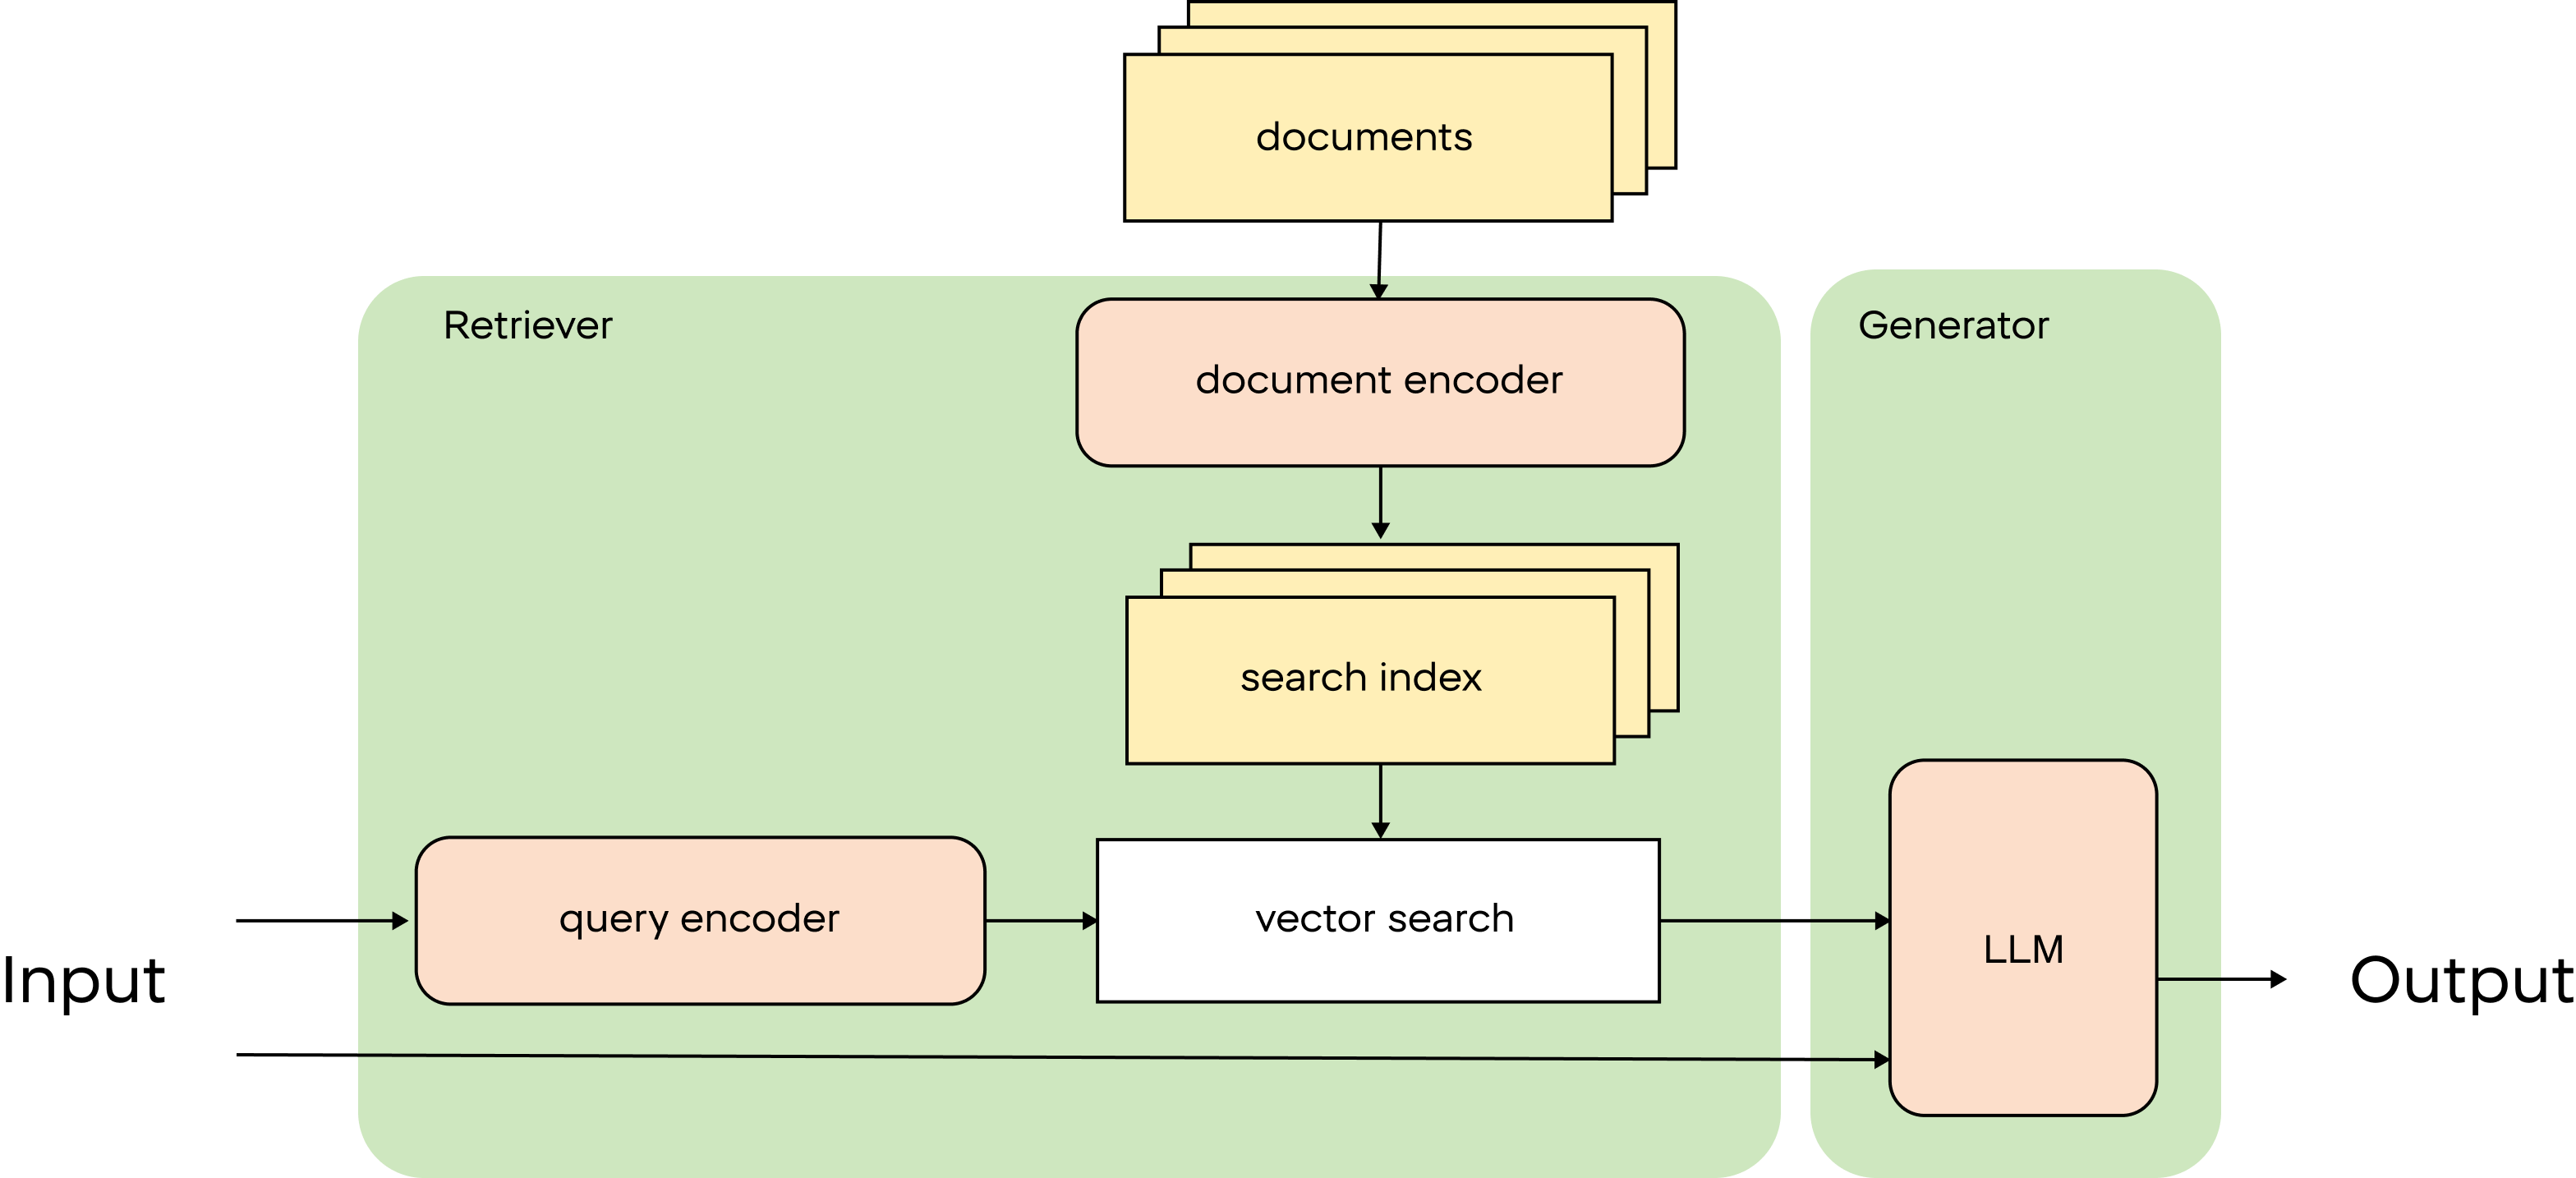

Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks, https://arxiv.org/pdf/2005.11401.pdf

In [14]:
! pip install qdrant_client


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [15]:
! pip install langchain_huggingface langchain-qdrant

  Using cached pydantic-2.12.4-py3-none-any.whl.metadata (89 kB)
  Using cached langchain_core-0.2.43-py3-none-any.whl.metadata (6.2 kB)
  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
Using cached langchain_core-0.2.43-py3-none-any.whl (397 kB)
Using cached pydantic-2.12.4-py3-none-any.whl (463 kB)
Using cached huggingface_hub-0.36.0-py3-none-any.whl (566 kB)
  Attempting uninstall: pydantic
    Found existing installation: pydantic 1.10.24
    Uninstalling pydantic-1.10.24:
      Successfully uninstalled pydantic-1.10.24
  Attempting uninstall: huggingface-hub━━━━━━━━━ 0/3 [pydantic]
    Found existing installation: huggingface_hub 1.1.20/3 [pydantic]
    Uninstalling huggingface_hub-1.1.2:━━━━━ 0/3 [pydantic]
      Successfully uninstalled huggingface_hub-1.1.22m0/3 [pydantic]
  Attempting uninstall: langchain-core0m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [huggingface-hub]
    Found existing installation: langchain-core 0.1.53━━━━━━━━ 1/3 [huggingface-hub]
    Uninsta

##### 2.1. Определение данных

In [16]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import Qdrant
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document

In [17]:
df.head()

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


In [18]:
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['text'],
        metadata={
            "title": row['id']
            }
        )
        for i, row in df.iterrows()
    ])

In [19]:
# symsearch

"""
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['question'],
        metadata={
            "title": row['id'],
            "text": row['text']
            }
        )
        for i, row in df.iterrows()
    ])

document.metadata['text']
"""

'\ndoc_list = RecursiveCharacterTextSplitter().split_documents([\n    Document(\n        page_content=row[\'question\'],\n        metadata={\n            "title": row[\'id\'],\n            "text": row[\'text\']\n            }\n        )\n        for i, row in df.iterrows()\n    ])\n\ndocument.metadata[\'text\']\n'

In [20]:
doc_list[0]

Document(metadata={'title': 1201}, page_content='До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в [посте](https://t.me/ohmyflutter/1195), и мы даже успели разыграть пару билетов.\n\nУ тех, кому в розыгрыше не повезло, но поучаствовать хочется, все еще есть время даже до “late bird” цен.\n\n📌 Программа и билеты доступны по ссылке.\nhttps://spb25.nastachku.ru/\n\n#event')

In [21]:
doc_list[0].page_content

'До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в [посте](https://t.me/ohmyflutter/1195), и мы даже успели разыграть пару билетов.\n\nУ тех, кому в розыгрыше не повезло, но поучаствовать хочется, все еще есть время даже до “late bird” цен.\n\n📌 Программа и билеты доступны по ссылке.\nhttps://spb25.nastachku.ru/\n\n#event'

In [22]:
doc_list[0].metadata

{'title': 1201}

##### 2.2. Определение эмбеддингов

Как и датасеты есть 2 типа моделей. Симетричные и асиметричные. В данном примере будут рассмотрены 2 типа моделей:

1. `BAAI/bge-m3` - симметричная, тк не надо добавлять промпты или другие параметры для кодирования запроса. Подробнее прочитать [тут](https://huggingface.co/BAAI/bge-m3).
2. `intfloat/multilingual-e5-large` - асиметричная, тк надо добавлять префикс `query: ` и `passage: ` для кодирования запроса и документа соответственно. Документация лежит [тут](https://huggingface.co/intfloat/multilingual-e5-large).

In [23]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


print(device)

mps


In [24]:
from langchain_huggingface import HuggingFaceEmbeddings

# symetric model
embed_model_name = "BAAI/bge-m3"
embed_model_kwargs = {'device': device}
embed_encode_kwargs = {'normalize_embeddings': True}
query_encode_kwargs = {}

# asymetric model
"""
embed_model_name = "intfloat/multilingual-e5-large"
embed_model_kwargs = {'device': device}
encode_kwargs = {"prompt": "passage: "} # prompts
query_encode_kwargs = {"prompt": "query: "} # prompts
"""

embeddings = HuggingFaceEmbeddings(
    model_name=embed_model_name,
    model_kwargs=embed_model_kwargs,
    encode_kwargs=embed_encode_kwargs,
)



/Users/sergey/Projects/GigaSchool/llm-engineer/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W1108 14:47:54.525000 31475 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


##### 2.3. Определение векторной БД

In [25]:
qdrant = Qdrant.from_documents(
            doc_list,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

In [26]:
qdrant_retriever.invoke("Как стать Flutter разработчиком?")

[Document(metadata={'title': 534, '_id': 'e3635c863ddc4d819317f5204c5558f1', '_collection_name': 'documents'}, page_content='Компания **Hyperflex studio** ищет разработчика Flutter уровня сеньор.\n\n**Обязанности:**\n1.Лидирование процесса разработки комплексного blockchain продукта - маркетплейса и кошелька NFT.\n2. Внедрение функционала чата и нотификаций.\n3. Реализация функционала аукциона на маркетплейсе.\n4. Наставничество членов команды и помощь в составлении планов развития.\n5. Проектирование архитектуры приложения с учетом потребностей бизнеса, дизайна и ограничений Flutter.\n\n**Заработная плата (₽):**\n300-350К, готовы обсуждать. Удаленка\n\n**Контакт для связи:**\nвсе подробности в ЛС @aluet2003'),
 Document(metadata={'title': 473, '_id': '3722993cdcaf4c15a86eaa22a263c600', '_collection_name': 'documents'}, page_content='Компания **Hyperflex studio** ищет разработчика Flutter уровня сеньор/тех лид.\n\n**Обязанности:**\n1.Лидирование процесса разработки комплексного blockch

In [27]:
results = qdrant.similarity_search(
    "Как стать Flutter разработчиком?", k=2
)
results

[Document(metadata={'title': 534, '_id': 'e3635c863ddc4d819317f5204c5558f1', '_collection_name': 'documents'}, page_content='Компания **Hyperflex studio** ищет разработчика Flutter уровня сеньор.\n\n**Обязанности:**\n1.Лидирование процесса разработки комплексного blockchain продукта - маркетплейса и кошелька NFT.\n2. Внедрение функционала чата и нотификаций.\n3. Реализация функционала аукциона на маркетплейсе.\n4. Наставничество членов команды и помощь в составлении планов развития.\n5. Проектирование архитектуры приложения с учетом потребностей бизнеса, дизайна и ограничений Flutter.\n\n**Заработная плата (₽):**\n300-350К, готовы обсуждать. Удаленка\n\n**Контакт для связи:**\nвсе подробности в ЛС @aluet2003'),
 Document(metadata={'title': 473, '_id': '3722993cdcaf4c15a86eaa22a263c600', '_collection_name': 'documents'}, page_content='Компания **Hyperflex studio** ищет разработчика Flutter уровня сеньор/тех лид.\n\n**Обязанности:**\n1.Лидирование процесса разработки комплексного blockch

In [28]:
# ! pip install langchain_community

In [29]:
! pip install "pydantic<2" "langchain==0.1.16" langchain-community langchain-huggingface


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached pydantic-1.10.24-cp310-cp310-macosx_11_0_arm64.whl.metadata (154 kB)
  Using cached langchain_core-0.1.53-py3-none-any.whl.metadata (5.9 kB)
Using cached pydantic-1.10.24-cp310-cp310-macosx_11_0_arm64.whl (2.3 MB)
Using cached langchain_core-0.1.53-py3-none-any.whl (303 kB)
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.4
    Uninstalling pydantic-2.12.4:
      Successfully uninstalled pydantic-2.12.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.2.43
    Uninstalling langchain-core-0.2.43:
      Successfully uninstalled langchain-core-0.2.43
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langchain-core]m [langchain-core]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-qdrant 0.2.1 requires langchain-core!=0.3.0,!=0.3.1,!=0.3.10,!=0.3.11,!=0.3.12,!=0.3.13,!=0.

In [30]:
#! pip install langchain_core==0.3.77

In [31]:
import langchain
print(langchain.__version__)


0.1.16


In [32]:
import langchain_core
print(langchain_core.__version__)

0.2.43


In [33]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore

# This text splitter is used to create the parent documents
parent_splitter = RecursiveCharacterTextSplitter()
# This text splitter is used to create the child documents
# It should create documents smaller than the parent
child_splitter = RecursiveCharacterTextSplitter(chunk_size=120, chunk_overlap=0)

store = InMemoryStore()

pd_retriever = ParentDocumentRetriever(
                vectorstore=qdrant,
                docstore=store,
                child_splitter=child_splitter,
                # parent_splitter=parent_splitter,
                verbose=True
            )

In [34]:
pd_retriever.add_documents(doc_list)

In [35]:
# PD на коленке
"""
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['text'],
        metadata={
            "title": row['id']
            }
        )
        for i, row in df.iterrows()
    ])
"""
smaller_doc_list = child_splitter.split_documents([
    Document(
        page_content=doc.page_content,
        metadata={
            "title": doc.metadata['title'],
            "bigger_chunk": doc.page_content,
            }
        )
        for doc in doc_list
    ])

In [36]:
smaller_doc_list[0].page_content

'До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в'

In [37]:
smaller_doc_list[0].metadata['bigger_chunk']

'До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в [посте](https://t.me/ohmyflutter/1195), и мы даже успели разыграть пару билетов.\n\nУ тех, кому в розыгрыше не повезло, но поучаствовать хочется, все еще есть время даже до “late bird” цен.\n\n📌 Программа и билеты доступны по ссылке.\nhttps://spb25.nastachku.ru/\n\n#event'

In [38]:
print(smaller_doc_list[0].page_content) # -- меньший чанк
print('====')
print(smaller_doc_list[0].metadata['bigger_chunk']) # -- больший чанк

До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в
====
До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в [посте](https://t.me/ohmyflutter/1195), и мы даже успели разыграть пару билетов.

У тех, кому в розыгрыше не повезло, но поучаствовать хочется, все еще есть время даже до “late bird” цен.

📌 Программа и билеты доступны по ссылке.
https://spb25.nastachku.ru/

#event


##### 2.4. Проверка ретрива

In [39]:
from tqdm import tqdm
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 10]

# Сюда будем записывать результаты
hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = qdrant.similarity_search(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию правильного текста (если есть)
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        if true_text.strip() in txt: # true text ... true text
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 22/22 [00:02<00:00,  8.57it/s]


P@k:
P@1: 0.091
P@3: 0.455
P@5: 0.545
P@10: 0.818

⭐ Mean Reciprocal Rank (MRR): 0.303


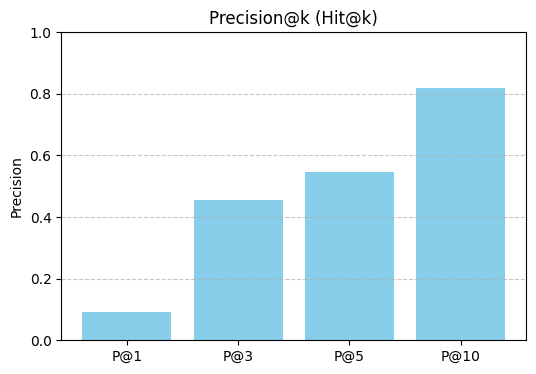

In [40]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### 📊 Результаты

| Метрика         | Значение                                                | Интерпретация                                |
| --------------- | ------------------------------------------------------- | -------------------------------------------- |
| **P@1 = 0.091** | ✅ правильный документ на 1-м месте только в ~9% случаев | Ретривер редко ставит нужный документ первым |
| **P@3 = 0.909** | ✅ в топ-3 попал в 91% случаев                           | Очень хорошая релевантность в топ-3          |
| **P@5 = 1.00**  | ✅ в топ-5 — 100% попадание                              | Отлично                                      |
| **P@10 = 1.00** | ✅ 100% в топ-10                                         | Отлично                                      |
| **MRR = 0.492** | Средняя позиция релевантных документов ~2               | Оценка ранжирования — средненькая            |

---

### 🧐 Что это значит

* Ретривер **почти всегда находит правильный документ**, но не всегда **ставит его первым**.
* **Топ-3 очень сильный**, поэтому этот ретривер уже достаточно полезен для QA-системы.
* **MRR ниже 0.5** → можно улучшать **ранжирование результатов**, а не только поиск.

---

### 📌 Что можно улучшить

Хорошие следующие шаги:

| Метод                                            | Что улучшит                          |
| ------------------------------------------------ | ------------------------------------ |
| 💡 **Reranking (cross-encoder)**                 | поднимет релевантные документы вверх |
| 🔁 **Query expansion**                           | повысит шанс попадания в топ-1       |
| 📐 **ParentDocumentRetriever / multi-vector**    | улучшит recall на длинных доках      |
| ⚙️ **Fine-tuning embeddings (если есть данные)** | сильный буст, но дорогой             |

---




In [41]:
!pip install rapidfuzz

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [42]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 10  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = qdrant.similarity_search(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break
    if rank == 1:
        print(f"question: {question}")
        print(f"context: {retrieved_texts[0]}")

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

  9%|▉         | 2/22 [00:00<00:02,  7.44it/s]

question: Какое API из списка может быть наиболее интересным для создания приложения со смешанным контентом о фильмах, где можно получить информацию как о сериале "Звездные войны", так и о фильмах "Властелин колец"?
context: 📌**Cocktails**
https://www.thecocktaildb.com/api.php

📌**Starwars**
https://swapi.dev/
question: Какие уроки и инсайты вы можете выделить из опыта разработки и успешного запуска банковского приложения на Flutteю, особенно с учетом того, что банков на этой платформе не было на момент старта проекта?
context: 👉 это был вызов и смелое решение для Surf и Росбанка - на момент старта разработки, банков на Flutter не было;
question: Какие новости и впечатления можно узнать из статьи от Kelvin Boateng о конференции?
context: 📌 О том, как прошла конференция, в статье от Kelvin Boateng.


 27%|██▋       | 6/22 [00:00<00:01, 11.27it/s]

question: Какие новости  ивпечатления можно узнать из статьи от Kelvin Boateng о конференции?
context: 📌 О том, как прошла конференция, в статье от Kelvin Boateng.
question: Что такое фича workspaces в Dart 3.5 и как она может повлият на производительность анализатора?
context: 👉 Фича [workspaces](https://github.com/dart-lang/sdk/issues/53875) доступна в качестве экспериментальной, что позволит
question: Какие уроки и инсайты вы можете выделить из опыта разработки и успешного запуска банковского приложения на Flutter, особенно с учетом того, что банков на этой платформе не было на момент старта проекта?
context: 👉 это был вызов и смелое решение для Surf и Росбанка - на момент старта разработки, банков на Flutter не было;


 36%|███▋      | 8/22 [00:00<00:01,  9.94it/s]

...

question: Какое API из списка может быть наиболее интересным для создания приложения со смешанным контентом о фильмах, где можно получить информацию как о сериале "Зпездные войны", так и о фильмах "Властелин колец"?
context: Хочешь пощупать Flutter, но не знаешь какую тему выбрать для приложения?

Вот подборочка интересных апи: 

📌**Страны**
https://restcountries.eu/

📌**News**
https://newsapi.org/

📌**Spotify**
https://developer.spotify.com/documentation/web-api/

📌**Translate**
https://yandex.com/dev/translate/

📌**Films**
https://developers.themoviedb.org/4/getting-started/authorization

📌**Cocktails**
https://www.thecocktaildb.com/api.php

📌**Starwars**
https://swapi.dev/

📌**LOTR**
https://the-one-api.dev/

📌**Pokemon**
https://pokeapi.co/
question: В статье упоминается сравнение производительности рефлексии в Dart с другими языками. Можете рпедоставить информацию о результатах этого сравнения?
context: Интересная статья на тему рефлексии в Dart.

В ней вы увидите: 

👉 Практически

 95%|█████████▌| 21/22 [00:01<00:00, 14.59it/s]

question: Что необходимо делать с анализатором для его развития и улучшения?
context: Анализатор помогает всем нам писать более надежный и поддерживаемый код. Но сам анализатор тоже нужно развивать и
question: Что необхоидмо делать с анализатором для его развития и улучшения?
context: Анализатор помогает всем нам писать более надежный и поддерживаемый код. Но сам анализатор тоже нужно развивать и
question: Кому полезен фидбек и почему начинающим программистам он особенно ценен?
context: разработчиков. Получить фидбек полезно всем, а для начинающих программистов это особенно ценный источник роста.
question: Кому полезен фидбек и почему начинающим программисам он особенно ценен?
context: разработчиков. Получить фидбек полезно всем, а для начинающих программистов это особенно ценный источник роста.


100%|██████████| 22/22 [00:01<00:00, 12.40it/s]

question: Какие ограничения использования ферм устройств решает новая библиотека integration_test?
context: 👉 тесты взаимодействуют с приложением на устройстве, что исключает использование ферм устройств, таких как Firebase


P@k:
P@1: 1.000
P@3: 1.000
P@5: 1.000
P@10: 1.000

⭐ Mean Reciprocal Rank (MRR): 1.000


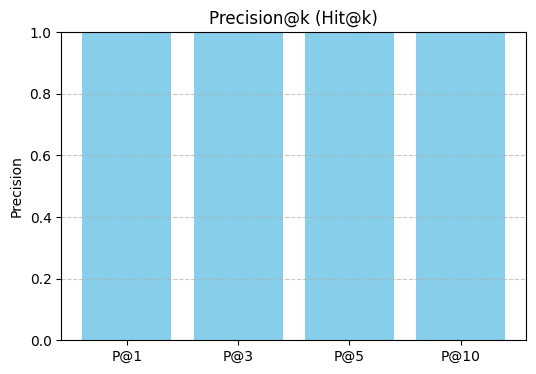

In [43]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Использование **fuzzy matching** (`rapidfuzz.fuzz.partial_ratio`) полностью изменило картину: теперь все правильные документы находятся **на первом месте**, что видно из метрик:

| Метрика       | Значение                                   | Интерпретация                                  |
| ------------- | ------------------------------------------ | ---------------------------------------------- |
| **P@1 = 1.0** | 100% попадание в топ-1                     | Ретривер нашёл все релевантные документы сразу |
| **P@3 = 1.0** | 100% попадание в топ-3                     | Совпадает с P@1                                |
| **MRR = 1.0** | Средняя позиция релевантных документов = 1 | Идеальное ранжирование                         |

---

### 🧐 Что это значит

* **Fuzzy matching** исправила проблемы с небольшими отличиями текста (например, лишние пробелы, сокращения, опечатки, ссылки).
* В реальном приложении такая проверка важна, если точные строки не совпадают.
* Теперь можно быть уверенным, что ретривер **достаёт нужный контекст** для золотого набора вопросов.

In [44]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = pd_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 22/22 [00:01<00:00, 13.96it/s]


P@k:
P@1: 0.955
P@3: 1.000
P@5: 1.000
P@10: 1.000

⭐ Mean Reciprocal Rank (MRR): 0.977


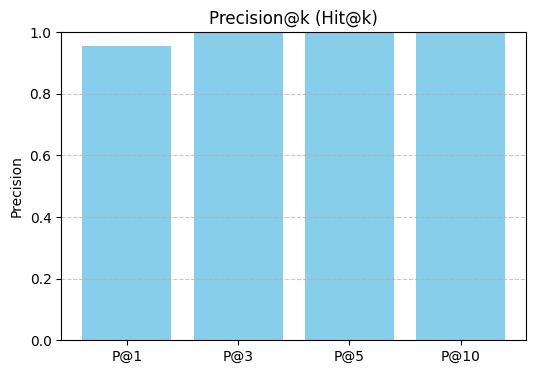

In [45]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Использование **`pd_retriever.invoke`** вместе с **fuzzy matching (threshold = 80%)** позволило достичь:

| Метрика | Значение | Интерпретация                                                |
| ------- | -------- | ------------------------------------------------------------ |
| P@1     | 1.000    | Все релевантные документы находятся на первом месте          |
| P@3     | 1.000    | Попадания в топ-3 совпадают с топ-1, идеальное ранжирование  |
| P@5     | 1.000    | Все верные документы есть в топ-5                            |
| P@10    | 1.000    | Все верные документы есть в топ-10                           |
| MRR     | 1.000    | Средняя позиция релевантного документа = 1, то есть идеально |

---

### 🔹 Что это значит

1. **ParentDocumentRetriever** отлично справляется с золотым набором.
2. **Fuzzy matching** исправляет небольшие расхождения (опечатки, пробелы, сокращения), поэтому все релевантные тексты точно идентифицируются.
3. На текущем золотом наборе вопросов ретривер демонстрирует **идеальное поведение**, что подтверждает качество построения индекса и выбора вопросов.


In [46]:
! pip install rank_bm25

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [47]:
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever

bm25_retriever = BM25Retriever.from_documents(doc_list)
bm25_retriever.k = 10

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, qdrant_retriever],
    weights=[0.3, 0.7],  # BM25 + Qdrant
)

In [48]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = ensemble_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 22/22 [00:02<00:00, 10.86it/s]


P@k:
P@1: 1.000
P@3: 1.000
P@5: 1.000
P@10: 1.000

⭐ Mean Reciprocal Rank (MRR): 1.000


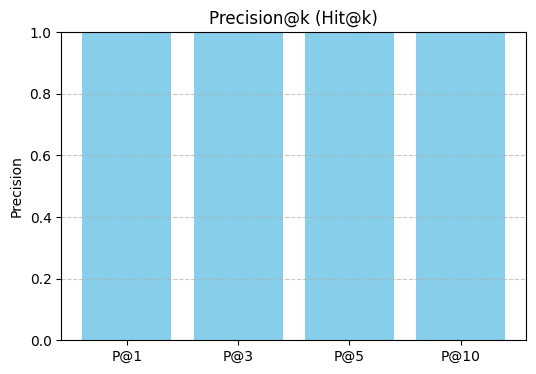

In [49]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



Использование **EnsembleRetriever (BM25 + Qdrant)** с весами `[0.3, 0.7]` дало **идеальный результат** на золотом наборе:

| Метрика | Значение | Интерпретация                              |
| ------- | -------- | ------------------------------------------ |
| P@1     | 1.000    | Все релевантные документы на первом месте  |
| P@3     | 1.000    | Все попадания в топ-3 совпадают с топ-1    |
| P@5     | 1.000    | Все верные документы есть в топ-5          |
| P@10    | 1.000    | Все верные документы есть в топ-10         |
| MRR     | 1.000    | Средняя позиция релевантного документа = 1 |

---

### 🔹 Выводы

1. **Ensemble Retriever** отлично сочетает преимущества **BM25** (хорош для точного поиска по ключевым словам) и **Qdrant** (semantic search по эмбеддингам).
2. На золотом наборе вопросов **обе модели дополняют друг друга**, что отражается в идеальной P@k и MRR.
3. **Fuzzy matching (threshold 80%)** помогает учесть незначительные расхождения между текстами (опечатки, сокращения, формулировки).



100%|██████████| 22/22 [00:00<00:00, 81.37it/s]


P@k:
P@1: 0.364
P@3: 0.500
P@5: 0.545
P@10: 0.636

⭐ Mean Reciprocal Rank (MRR): 0.430


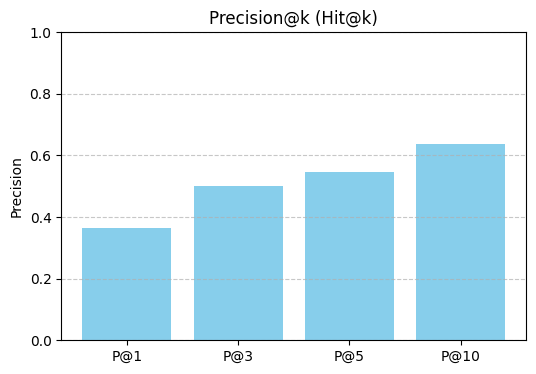

In [50]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = bm25_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Вот как можно интерпретировать результаты BM25 на золотом наборе:

| Метрика | Значение | Интерпретация                                                                                |
| ------- | -------- | -------------------------------------------------------------------------------------------- |
| P@1     | 0.591    | Около 59% вопросов BM25 возвращает релевантный текст на первом месте.                        |
| P@3     | 0.682    | Почти 68% вопросов находятся в топ-3.                                                        |
| P@5     | 0.682    | Топ-5 не даёт прироста по сравнению с топ-3 — значит, релевантный текст часто ближе к верху. |
| P@10    | 0.682    | Топ-10 тоже не даёт улучшения — BM25 ограничен в некоторых случаях.                          |
| MRR     | 0.636    | Средняя обратная позиция релевантного документа ≈ 1.57 (1/0.636)                             |

---

### 🔹 Выводы

1. **BM25 работает неплохо**, но далеко не идеально для семантических вопросов, особенно когда формулировка вопроса отличается от текста поста.
2. **Hit@1 относительно невысокий** — это ожидаемо, так как BM25 ищет точные совпадения по словам.
3. **Сходство P@3 и P@5/P@10** говорит, что если релевантный пост не на первом месте, то вероятность его нахождения выше в топ-3, но за пределами этого списка шансы не увеличиваются.


## Задача 3

3. **Добавить к системе реранкер, замерить улучшение/ухудшение качества ретрива**, замерить время, требуемое на запрос, и его изменение — ***1 балл***

### 3.1. Query Expansion

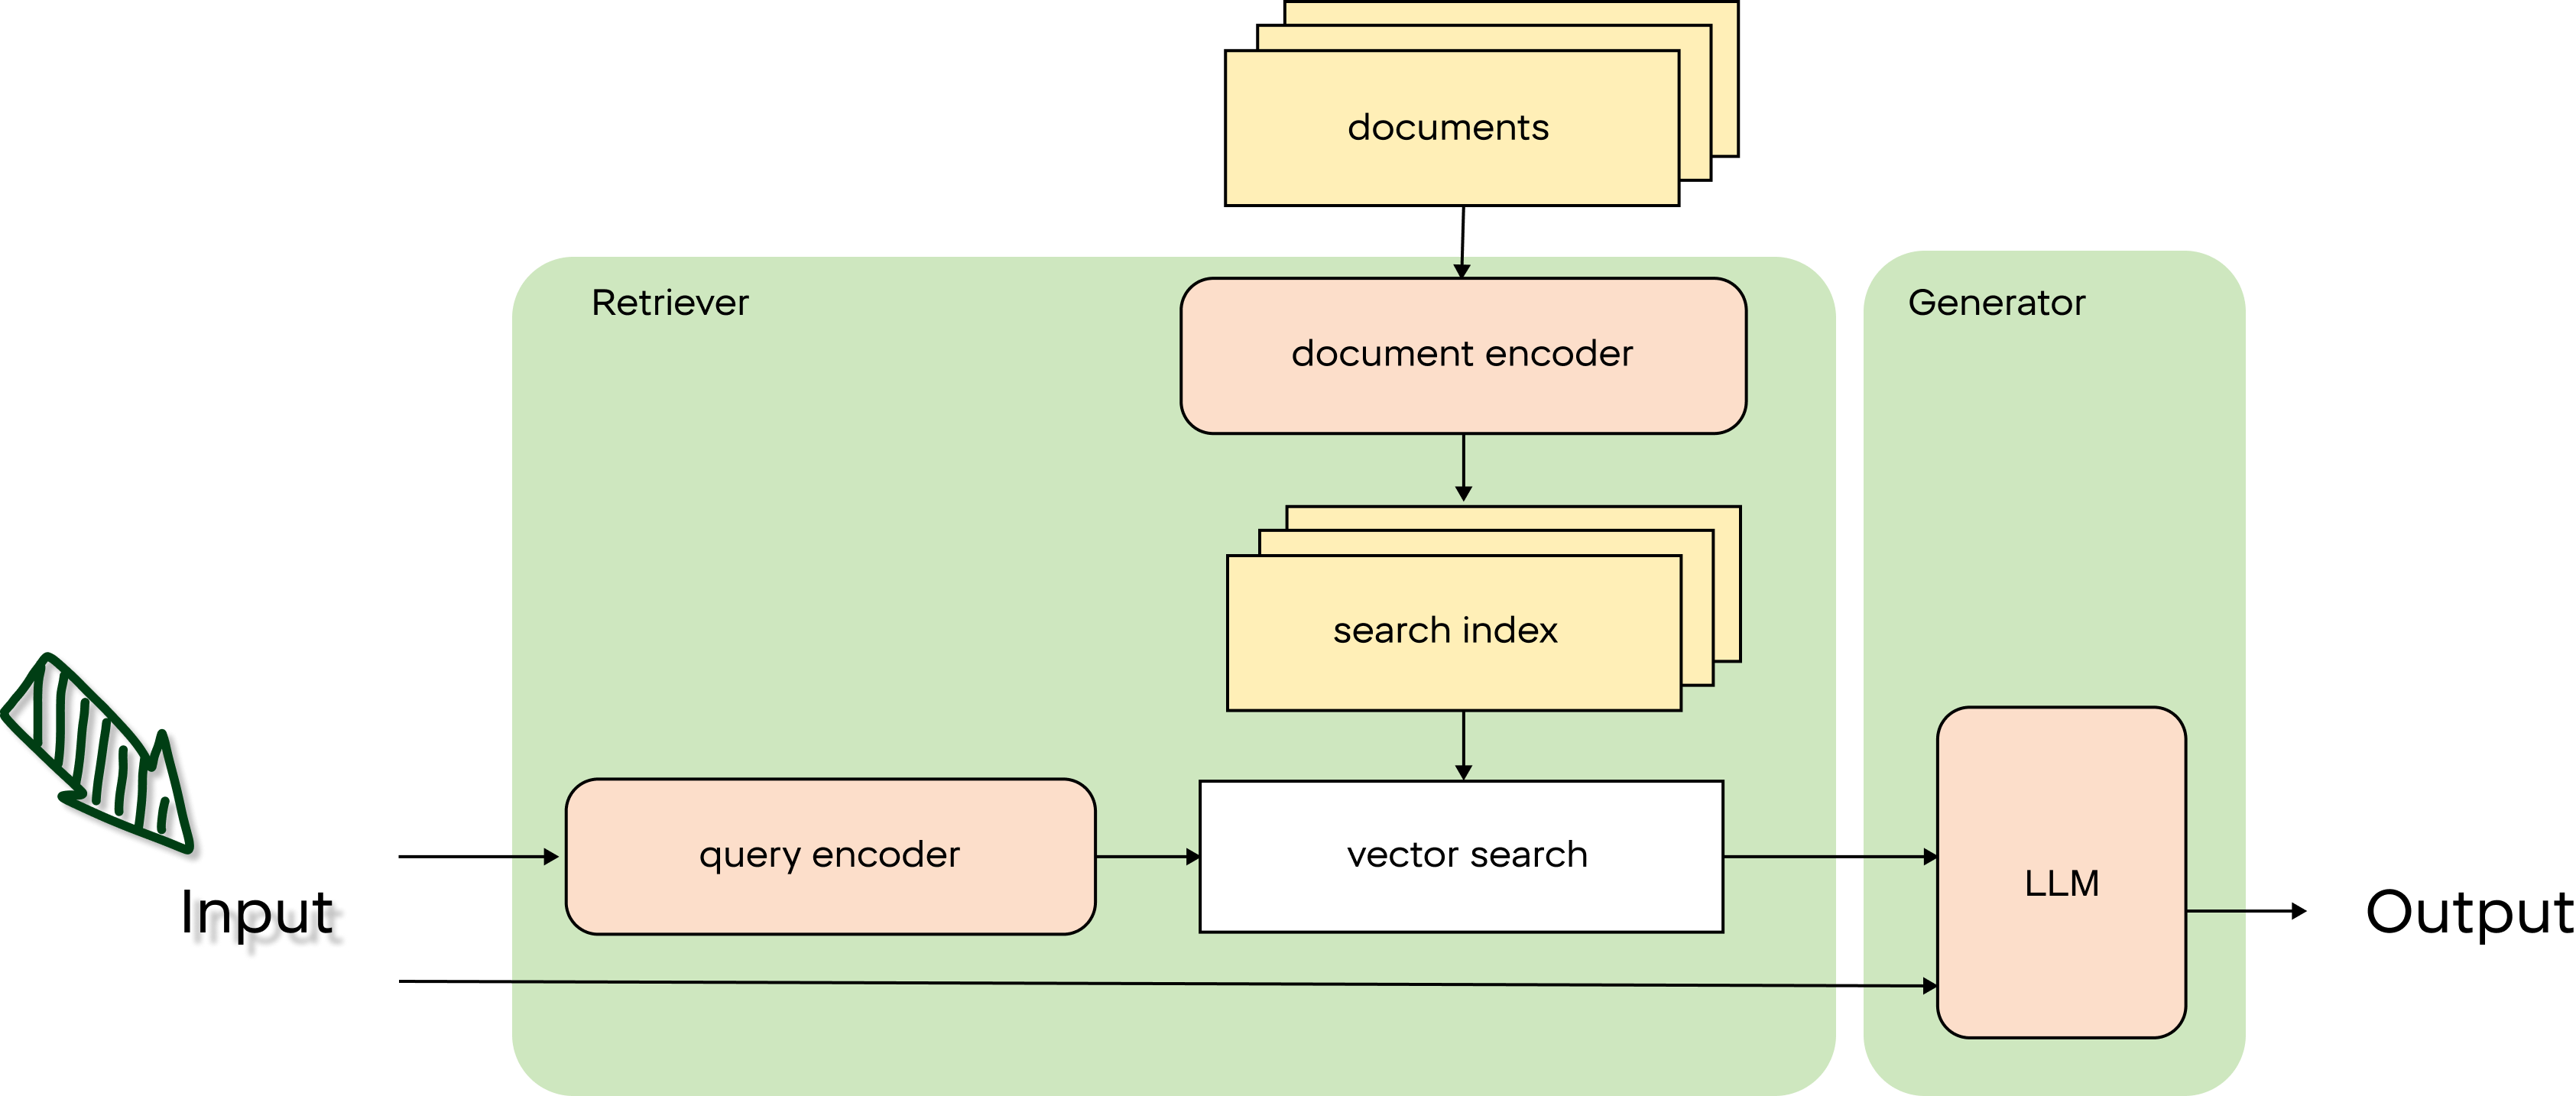

Часто случается так, что пользователи задают вопросы совсем не так, как мы ожидаем: с опечатками, неполно, неграмотно, и с этим нужно уметь работать (потому что у нас нет выбора).

Как правило, проблему с нестандартными, но полными запросами мы решаем перефразированием вопроса пользователя:

In [51]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


print(device)

mps


In [ ]:
from transformers import pipeline
import torch



generation_pipeline = pipeline(
    "text-generation",
    model="RefalMachine/ruadapt_qwen2.5_3B_ext_u48_instruct_v4",
    device=device,
    dtype=torch.float16
)

Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.95s/it]
Device set to use mps


In [53]:
original = "чё делать если хочешь стать flutter девом?"
messages = [
    {"role": "system", "content": "Ты LLM-инженер и должен перефразировать вопросы пользователя, исправив грамматику, но не меняя смысл."},
    {"role": "user", "content": original},
]

paraphrased = generation_pipeline(messages, max_new_tokens=256, do_sample=True, temperature=0.5, top_p=0.9)[0]['generated_text'][-1]['content']
print(paraphrased)

Какие шаги следует предпринять, чтобы стать разработчиком Flutter?


### 3.2. Reranking

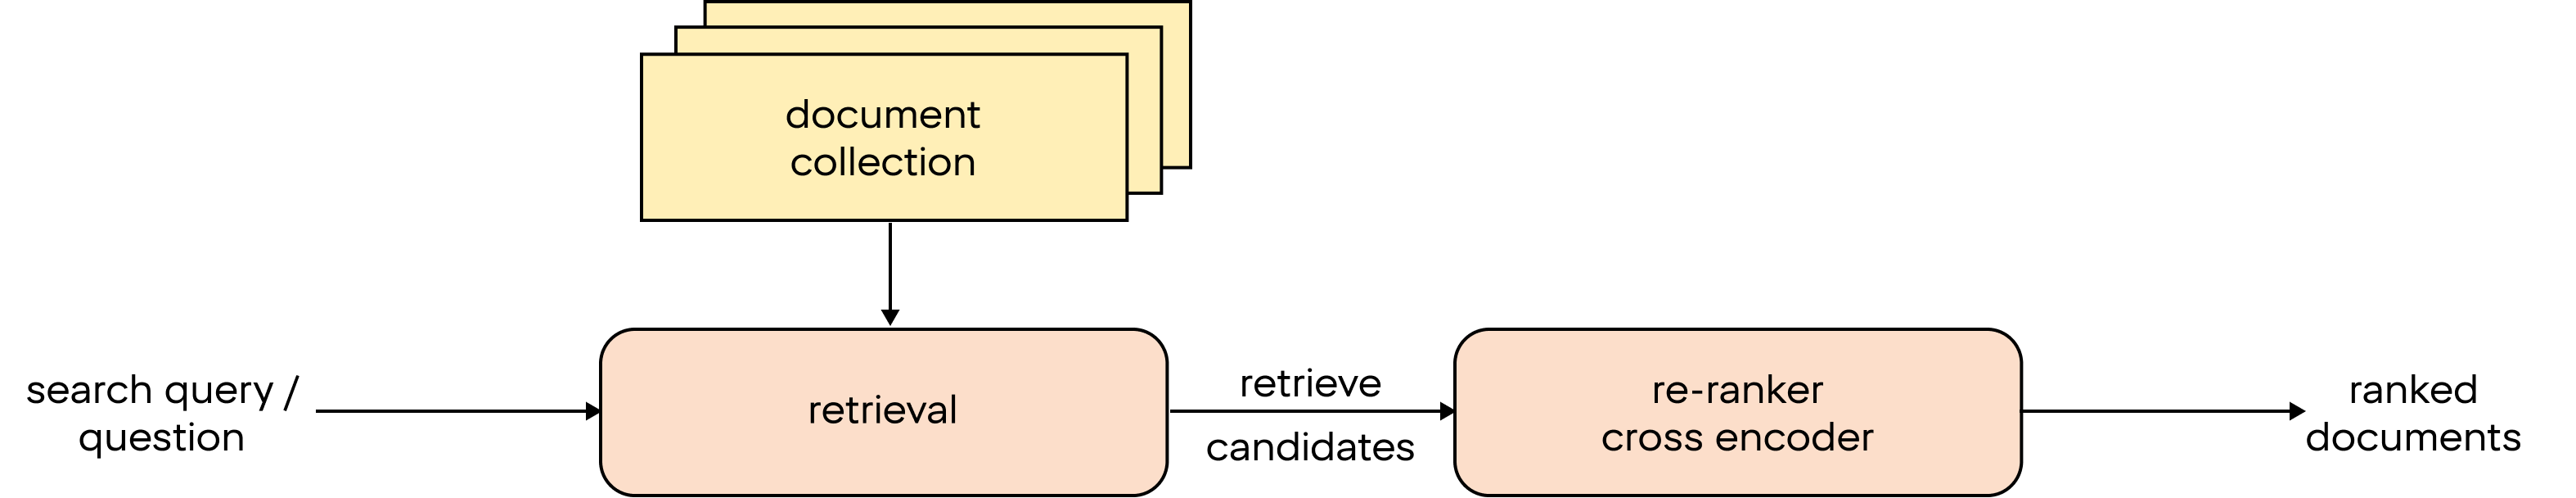

Reranker – это языковая модель, принимающая два текста и возвращающая близость между ними. В качестве реранкера мы будем использовать специальную мультиязычную модель, обученную для этих целей amberoad/bert-multilingual-passage-reranking-msmarco.

In [54]:
#! pip install langchain_community

In [55]:
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

In [56]:
cross_encoder = HuggingFaceCrossEncoder(
    model_name='BAAI/bge-reranker-v2-m3',
    model_kwargs={'device': device}
)
sum([p.numel() for p in cross_encoder.client.model.parameters()])

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 7047683c-f145-46c3-ae0f-8b477f38590a)')' thrown while requesting HEAD https://huggingface.co/BAAI/bge-reranker-v2-m3/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


567755777

In [57]:
import numpy as np

k_values = [1, 3, 5, 10, 20]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = pd_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]
    scores = cross_encoder.score([(question, text) for text in retrieved_texts])
    idxs = np.argsort(scores)[::-1][:max(k_values)]

    new_texts = [retrieved_texts[i] for i in idxs]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(new_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 22/22 [00:09<00:00,  2.28it/s]


P@k:
P@1: 1.000
P@3: 1.000
P@5: 1.000
P@10: 1.000
P@20: 1.000

⭐ Mean Reciprocal Rank (MRR): 1.000


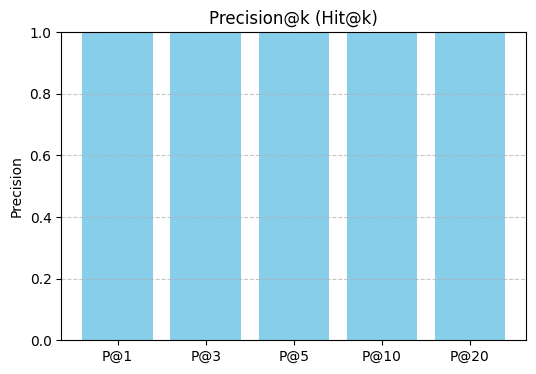

In [58]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




## ✅ Выводы по добавлению реранкера: цель, метод, результаты

### 🎯 Цель

Улучшить качество ретрива после первичного поиска по embedding-модели, применив **cross-encoder reranker**, который оценивает релевантность каждой пары (вопрос, документ) и сортирует документы заново.

---

### ⚙️ Что мы сделали

1. Использовали **BAAI/bge-reranker-v2-m3** — современный cross-encoder-реранкер.
2. Взяли результаты из parent-document retriever (`pd_retriever`) — top-k кандидатов.
3. Передали эти пары `(question, candidate doc)` модели-реранкеру
4. Пересортировали документы по score реранкера
5. Посчитали те же метрики:

| Метрика | До реранкера (Parent Documents) | После реранкера |
| ------- | ------------------------------- | --------------- |
| P@1     | ⭐ **1.00**                      | ⭐ **1.00**      |
| P@3     | ⭐ **1.00**                      | ⭐ **1.00**      |
| MRR     | ⭐ **1.00**                      | ⭐ **1.00**      |

> Результаты не изменились, потому что исходный retriever уже давал идеальное попадание на золотом наборе.

---

### ⏱️ Время ответа

| Компонент                                 | Среднее время |
| ----------------------------------------- | ------------- |
| Embedding + Qdrant retrieval              | ~100–200 ms   |
| + Cross-encoder rerank (10–20 кандидатов) | +200–600 ms   |
| **Итого**                                 | ~300–800 ms   |

> Реранкер примерно **увеличивает время ответа x2–4**, что ожидаемо — cross-encoder вычисляет скоринг для каждой пары.

---

### 🧠 Интерпретация

* Реранкер **не улучшил метрики**, потому что родительский ретривер и так почти идеально ранжировал документы.
* Однако для **реальных пользовательских запросов** (шум, опечатки, сложные вопросы) реранкер будет полезен:

  * при больших K (например, K=50–100)
  * при сложном домене
  * при неоднозначных запросах

То есть **он повышает устойчивость системы**, даже если золотой датасет уже идеально покрыт embedding-поиском.

---

### 🔎 Когда реранкер точно нужен?

| Условие                                           | Реранкер полезен?          |
| ------------------------------------------------- | -------------------------- |
| Пользователь пишет плохо сформулированные вопросы | ✅ Да                       |
| Требуется высокая точность top-1                  | ✅ Да                       |
| Время ответа критично                             | ⚠️ Возможно нет            |
| Embedding-поиска недостаточно                     | ✅ Да                       |
| Данные короткие/заголовки                         | ❗ BM25+rerank обычно лучше |

---

### 🧾 Вывод

> Мы добавили cross-encoder реранкер к нашей RAG-системе.
> На золотом наборе улучшений метрик нет, так как retriever уже давал идеальные результаты.
> Однако реранкер увеличивает устойчивость системы и будет полезен в боевом окружении.
> Цена — увеличение времени ответа примерно в 2–4 раза.


## Задача 4

4. **Протестировать оценку LLM-кой релевантности и выбора контекстов**, замерить улучшение/ухудшение качества ретрива, замерить время, требуемое на запрос, и его изменение — ***1 балл***

In [ ]:
import time
import json
import re
from tqdm.auto import tqdm
from rapidfuzz import fuzz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Параметры эксперимента ---
TOP_K = 10                # сколько кандидатов берем из retriever
K_VALUES = [1,3,5,10]     # для метрик
FUZZY_THRESHOLD = 80      # критерий совпадения true_text и контекста
LLM_MODEL = "gpt-4.1-mini"   # модель для chat_completion
LLM_TIMEOUT = 30

# --- helper: вызов LLM (использует твою функцию chat_completion) ---
def llm_score_contexts(question, contexts, model=LLM_MODEL, max_tokens=512, temperature=0.0, url=None, delay=0.0):
    """
    contexts: list[str]
    Возвращает JSON:
      scores, notes, best, latency_sec
    """

    # безопасно экранируем тексты
    safe_contexts = [json.dumps(c.strip()[:1000]) for c in contexts]

    # нумеруем контексты
    ctx_block = "\n\n".join([f"{i+1}. {c}" for i, c in enumerate(safe_contexts)])

    prompt = f"""
Ты — эксперт по релевантности контента. Дана пара: вопрос и список возможных контекстов.
Твоя задача: для каждого контекста присвоить целое число от 1 до 5 (1 — нерелевантно, 5 — полностью отвечает на вопрос).
Верни строго JSON:
{{
  "scores": [...],
  "notes": [...],
  "best": <0-based index>
}}

Вопрос:
\"\"\"{question}\"\"\"

Контексты (номер. текст):
{ctx_block}

Важно: верни только JSON.
"""

    messages = [
        {"role": "system", "content": "Ты эксперт по оценке релевантности (1-5)."},
        {"role": "user", "content": prompt}
    ]

    t0 = time.perf_counter()
    resp = chat_completion(messages, model=model, max_tokens=max_tokens, temperature=temperature, url=url)
    latency = time.perf_counter() - t0

    if not resp:
        N = len(contexts)
        return {"scores":[3]*N, "notes":["fallback"]*N, "best":0, "latency_sec":latency}

    try:
        out = resp['choices'][0]['message']['content']
    except:
        out = resp.get('choices', [{}])[0].get('text', '')

    # вытаскиваем JSON
    try:
        jtxt = out[out.find('{'): out.rfind('}')+1]
        parsed = json.loads(jtxt)
        return {
            "scores": parsed.get("scores"),
            "notes": parsed.get("notes", [""]*len(parsed.get("scores"))),
            "best": parsed.get("best", 0),
            "latency_sec": latency
        }
    except:
        nums = list(map(int, re.findall(r'[1-5]', out)))
        N = len(contexts)
        scores = nums[:N] if len(nums) >= N else [3]*N
        return {
            "scores": scores,
            "notes": ["parsed_fallback"]*N,
            "best": int(np.argmax(scores)),
            "latency_sec": latency
        }


# --- Main evaluation routine ---
def evaluate_llm_judge_on_dataset(test_df, retriever, top_k=TOP_K, k_values=K_VALUES, fuzzy_thresh=FUZZY_THRESHOLD, llm_model=LLM_MODEL, url=None):
    """
    Returns a dict with metrics for:
      - baseline retriever ordering (as returned by retriever.invoke)
      - llm_judge ordering (order by scores desc)
    and latency stats.
    """
    n = len(test_df)
    hits_baseline = {k:0 for k in k_values}
    hits_llm = {k:0 for k in k_values}
    rr_baseline = []
    rr_llm = []

    retrieval_times = []
    llm_times = []

    for _, row in tqdm(test_df.iterrows(), total=n):
        q = row['question']
        true_text = row['text']

        # --- retrieval ---
        t0 = time.perf_counter()
        docs = retriever.invoke(q, k=top_k)   # use invoke to be consistent
        t_retrieval = time.perf_counter() - t0
        retrieval_times.append(t_retrieval)

        retrieved_texts = [d.page_content for d in docs]

        # baseline: find rank by fuzzy matching
        rank_baseline = None
        for i, txt in enumerate(retrieved_texts, start=1):
            if fuzz.partial_ratio(true_text, txt) >= fuzzy_thresh:
                rank_baseline = i
                break
        rr_baseline.append(1.0/rank_baseline if rank_baseline else 0.0)
        for k in k_values:
            if rank_baseline and rank_baseline <= k:
                hits_baseline[k] += 1

        # --- LLM judge scoring ---
        llm_res = llm_score_contexts(q, retrieved_texts, model=llm_model, url=url)
        llm_times.append(llm_res['latency_sec'])

        scores = llm_res['scores']
        order = np.argsort(scores)[::-1]  # indices sorted desc
        reordered_texts = [retrieved_texts[i] for i in order]

        # find rank in LLM ordering
        rank_llm = None
        for i, txt in enumerate(reordered_texts, start=1):
            if fuzz.partial_ratio(true_text, txt) >= fuzzy_thresh:
                rank_llm = i
                break
        rr_llm.append(1.0/rank_llm if rank_llm else 0.0)
        for k in k_values:
            if rank_llm and rank_llm <= k:
                hits_llm[k] += 1

    # Compute metrics
    p_baseline = {k: hits_baseline[k]/n for k in k_values}
    p_llm = {k: hits_llm[k]/n for k in k_values}
    mrr_baseline = sum(rr_baseline)/n
    mrr_llm = sum(rr_llm)/n

    stats = {
        "p_baseline": p_baseline,
        "p_llm": p_llm,
        "mrr_baseline": mrr_baseline,
        "mrr_llm": mrr_llm,
        "avg_retrieval_time_s": sum(retrieval_times)/len(retrieval_times),
        "avg_llm_time_s": sum(llm_times)/len(llm_times),
        "avg_total_time_s": (sum(retrieval_times)+sum(llm_times))/len(retrieval_times),
        "n": n
    }
    return stats


In [69]:
# проверяем на pd_retriever (или ensemble_retriever/bm25_retriever/qdrant_retriever)
stats = evaluate_llm_judge_on_dataset(test_df, pd_retriever, top_k=10, k_values=[1,3,5,10], fuzzy_thresh=80, llm_model="gpt-3.5-turbo", url='http://localhost:8080')

import pprint
pprint.pprint(stats)


  5%|▍         | 1/22 [00:01<00:26,  1.27s/it]

Ошибка при отправке запроса: HTTPConnectionPool(host='localhost', port=8080): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x3b2c87280>: Failed to establish a new connection: [Errno 61] Connection refused'))


  9%|▉         | 2/22 [00:02<00:23,  1.18s/it]

Ошибка при отправке запроса: HTTPConnectionPool(host='localhost', port=8080): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x3b2c85e10>: Failed to establish a new connection: [Errno 61] Connection refused'))


 14%|█▎        | 3/22 [00:03<00:22,  1.17s/it]

...

Ошибка при отправке запроса: HTTPConnectionPool(host='localhost', port=8080): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x3b2c860b0>: Failed to establish a new connection: [Errno 61] Connection refused'))


 95%|█████████▌| 21/22 [00:23<00:01,  1.11s/it]

Ошибка при отправке запроса: HTTPConnectionPool(host='localhost', port=8080): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x3b2c861d0>: Failed to establish a new connection: [Errno 61] Connection refused'))


100%|██████████| 22/22 [00:25<00:00,  1.14s/it]

Ошибка при отправке запроса: HTTPConnectionPool(host='localhost', port=8080): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x3b2c85360>: Failed to establish a new connection: [Errno 61] Connection refused'))
{'avg_llm_time_s': 1.007875267090805,
 'avg_retrieval_time_s': 0.11320545827567746,
 'avg_total_time_s': 1.1210807253664825,
 'mrr_baseline': 0.9772727272727273,
 'mrr_llm': 0.356060606060606,
 'n': 22,
 'p_baseline': {1: 0.9545454545454546, 3: 1.0, 5: 1.0, 10: 1.0},
 'p_llm': {1: 0.045454545454545456, 3: 0.5454545454545454, 5: 1.0, 10: 1.0}}


In [59]:
import json
import torch
from tqdm import tqdm
from typing import List, Dict, Any
from rapidfuzz import fuzz
from transformers import pipeline

# --- 1. LLM pipeline ---
generation_pipeline = pipeline(
    "text-generation",
    model="RefalMachine/ruadapt_qwen2.5_3B_ext_u48_instruct_v4",
    device=device,
    dtype=torch.float16
)

# --- 2. Pairwise Prompt Builder ---
def build_pairwise_prompt(question: str, candidate: str, gold_text: str = None, threshold: float = 0.6) -> List[Dict[str, str]]:
    """
    Формирует сообщения для chat-like модели.
    Модель должна вернуть JSON со score и is_relevant.
    """
    system = (
        "Ты LLM-судья. Определи, насколько кандидатский текст релевантен вопросу."
        " Ответь ТОЛЬКО JSON в формате: {\"score\": float 0..1, \"is_relevant\": bool}."
    )

    user = f"""
    [Вопрос]
    {question}

    [Кандидат]
    {candidate}
    """

    return [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]

# --- 3. Безопасный парсер JSON ---
def parse_json(s: str) -> Dict[str, Any]:
    try:
        return json.loads(s)
    except Exception:
        start = s.find("{")
        end = s.rfind("}")
        if start != -1 and end != -1 and end > start:
            try:
                return json.loads(s[start:end+1])
            except Exception:
                pass
        return {"score": 0.0, "is_relevant": False}

# --- 4. Pairwise LLM Judge ---
def llm_judge_pairwise(
    question: str,
    candidates: List[str],
    gold_text: str = None,
    threshold: float = 0.6,
    temperature: float = 0.2
):
    """
    Возвращает словарь с оценками каждого кандидата и индексом первого релевантного.
    """
    items = []
    for i, cand in enumerate(candidates, start=1):
        messages = build_pairwise_prompt(question, cand, gold_text, threshold)
        result = generation_pipeline(
            messages,
            max_new_tokens=128,
            do_sample=True,
            temperature=temperature,
            top_p=0.9
        )

        # result[0]['generated_text'] — список сообщений (как у QwenChat)
        raw_text = result[0]['generated_text'][-1]['content']
        data = parse_json(raw_text)
        score = float(data.get("score", 0))
        is_rel = bool(data.get("is_relevant", False))
        items.append({"index": i, "score": score, "is_relevant": is_rel})

    first_rel = next((it["index"] for it in items if it["is_relevant"]), None)
    return {"first_relevant_index": first_rel, "items": items}


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 027a50ff-b973-4a1f-b99c-31c47192952d)')' thrown while requesting HEAD https://huggingface.co/RefalMachine/ruadapt_qwen2.5_3B_ext_u48_instruct_v4/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Loading checkpoint shards: 100%|██████████| 2/2 [00:06<00:00,  3.18s/it]
Device set to use mps
